# 02 — Feature Engineering & EDA

- Загрузка OHLCV из `data/raw/{TICKER}_ohlcv.parquet`
- Технические признаки (RSI, MACD, Bollinger, ATR, OBV, EMA, volume ratio)
- Lag-признаки (returns/volatility/rsi со сдвигом)
- Анализ распределений, корреляций, целевой переменной
- Сохранение в `data/processed/{TICKER}/technical.parquet`

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'backend'))

RAW_DIR = ROOT / 'data' / 'raw'
PROCESSED_DIR = ROOT / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use('dark_background')
sns.set_palette('husl')

TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'NVDA', 'META', 'JPM', 'JNJ', 'V']
print(f'Root:      {ROOT}')
print(f'Raw:       {RAW_DIR}')
print(f'Processed: {PROCESSED_DIR}')

Root:      /Users/dimabogolaev/EquiSense
Raw:       /Users/dimabogolaev/EquiSense/data/raw
Processed: /Users/dimabogolaev/EquiSense/data/processed


## 1. Загрузка сырых данных

In [2]:
from app.features.technical import TechnicalFeatureEngineer
from app.features.constants import TECHNICAL_FEATURES, LAG_FEATURES


def load_ohlcv(ticker: str) -> pd.DataFrame:
    path = RAW_DIR / f'{ticker}_ohlcv.parquet'
    if not path.exists():
        print(f'[WARN] {ticker}: {path.name} not found')
        return pd.DataFrame()
    df = pd.read_parquet(path)
    if 'date' not in df.columns:
        df = df.reset_index()
        df = df.rename(columns={df.columns[0]: 'date'})
    df['date'] = pd.to_datetime(df['date']).dt.tz_localize(None)
    df.columns = df.columns.str.lower()
    return df


raw_frames = {t: load_ohlcv(t) for t in TICKERS}
available = {t: df for t, df in raw_frames.items() if not df.empty}

print(f'Загружено: {list(available.keys())}')
for t, df in available.items():
    print(f'  {t}: {len(df)} строк  {df["date"].min().date()} – {df["date"].max().date()}')

Загружено: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'NVDA', 'META', 'JPM', 'JNJ', 'V']
  AAPL: 1256 строк  2021-03-19 – 2026-03-19
  MSFT: 1256 строк  2021-03-19 – 2026-03-19
  GOOGL: 1256 строк  2021-03-19 – 2026-03-19
  AMZN: 1256 строк  2021-03-19 – 2026-03-19
  TSLA: 1256 строк  2021-03-19 – 2026-03-19
  NVDA: 1256 строк  2021-03-19 – 2026-03-19
  META: 1256 строк  2021-03-19 – 2026-03-19
  JPM: 1256 строк  2021-03-19 – 2026-03-19
  JNJ: 1256 строк  2021-03-19 – 2026-03-19
  V: 1256 строк  2021-03-19 – 2026-03-19


## 2. Вычисление признаков

In [3]:
engineer = TechnicalFeatureEngineer()
feature_frames = {}

for ticker, df in available.items():
    try:
        features = engineer.compute(df)
        features['ticker'] = ticker
        feature_frames[ticker] = features
        print(f'{ticker}: {len(features)} строк, {len(features.columns)} признаков')
    except Exception as e:
        print(f'[ERROR] {ticker}: {e}')

if not feature_frames:
    raise RuntimeError('Нет данных. Запустите ноутбук 01_data_collection.ipynb')

combined = pd.concat(feature_frames.values(), ignore_index=True)
print(f'\nВсего строк: {len(combined)}')
print(f'Колонки: {list(combined.columns)}')

AAPL: 1256 строк, 32 признаков
MSFT: 1256 строк, 32 признаков
GOOGL: 1256 строк, 32 признаков
AMZN: 1256 строк, 32 признаков
TSLA: 1256 строк, 32 признаков
NVDA: 1256 строк, 32 признаков
META: 1256 строк, 32 признаков
JPM: 1256 строк, 32 признаков
JNJ: 1256 строк, 32 признаков
V: 1256 строк, 32 признаков

Всего строк: 12560
Колонки: ['date', 'close', 'returns', 'volatility', 'rsi', 'macd', 'macd_signal', 'macd_hist', 'sma_20', 'sma_50', 'sma_200', 'bb_upper', 'bb_lower', 'bb_width', 'bb_pct', 'momentum', 'atr', 'obv_change', 'ema_12', 'ema_26', 'volume_ratio', 'price_vs_sma20', 'price_vs_sma50', 'returns_lag1', 'returns_lag2', 'returns_lag3', 'returns_lag5', 'volatility_lag5', 'rsi_lag3', 'volume_change', 'volume_lag1', 'ticker']


## 3. Анализ пропусков

Признаки с пропусками:
                 count   pct
momentum           100  0.80
volatility_lag5     70  0.56
returns_lag5        60  0.48
rsi_lag3            60  0.48
returns_lag3        40  0.32
rsi                 30  0.24
returns_lag2        30  0.24
volatility          20  0.16
returns_lag1        20  0.16
volume_lag1         20  0.16
returns             10  0.08
bb_upper            10  0.08
bb_lower            10  0.08
bb_width            10  0.08
bb_pct              10  0.08
volume_change       10  0.08


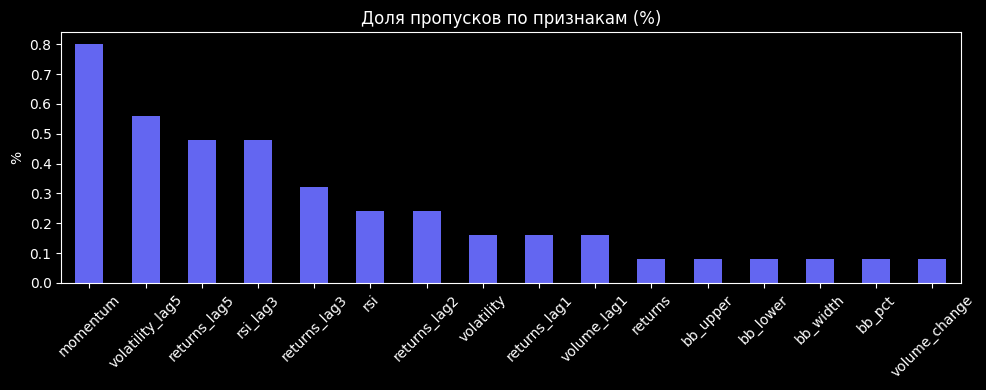

In [4]:
all_features = TECHNICAL_FEATURES + LAG_FEATURES

missing = combined[all_features].isnull().sum()
missing_pct = (missing / len(combined) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
missing_df = missing_df[missing_df['count'] > 0].sort_values('pct', ascending=False)

if missing_df.empty:
    print('Пропусков нет!')
else:
    print('Признаки с пропусками:')
    print(missing_df.to_string())
    fig, ax = plt.subplots(figsize=(10, 4))
    missing_df['pct'].plot(kind='bar', ax=ax, color='#6366f1')
    ax.set_title('Доля пропусков по признакам (%)')
    ax.set_ylabel('%')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

## 4. Статистика и распределения технических признаков

In [5]:
stats = combined[all_features].describe().T
stats['skew'] = combined[all_features].skew()
stats['kurt'] = combined[all_features].kurt()
print(stats[['mean', 'std', 'min', 'max', 'skew', 'kurt']].round(4).to_string())

                     mean       std       min       max    skew     kurt
returns            0.0009    0.0228   -0.2639    0.2437  0.3529  11.5378
volatility         0.0199    0.0112    0.0022    0.0758  1.4973   2.4706
rsi               53.5130   17.3301    0.0000   98.2443 -0.0045  -0.5500
macd               0.9548    5.8991  -35.5832   40.5386  0.1084   7.5933
macd_signal        0.9665    5.5417  -32.2386   34.7566  0.1026   7.2233
macd_hist         -0.0117    1.7879  -11.4152   13.1068  0.1149   7.7536
sma_20           218.7621  125.1936   12.2010  762.4568  1.4555   2.9890
sma_50           216.7546  123.6101   12.8135  752.1572  1.4604   3.0479
sma_200          206.8097  113.7899   12.8135  690.5625  1.4426   3.3624
bb_upper         233.3221  133.7954   13.2560  813.2580  1.4644   2.9952
bb_lower         204.2979  117.5775   10.8538  733.9517  1.4557   3.0193
bb_width           0.1384    0.0934    0.0052    0.7220  2.1371   6.4533
bb_pct             0.5521    0.3243   -0.4443    1.

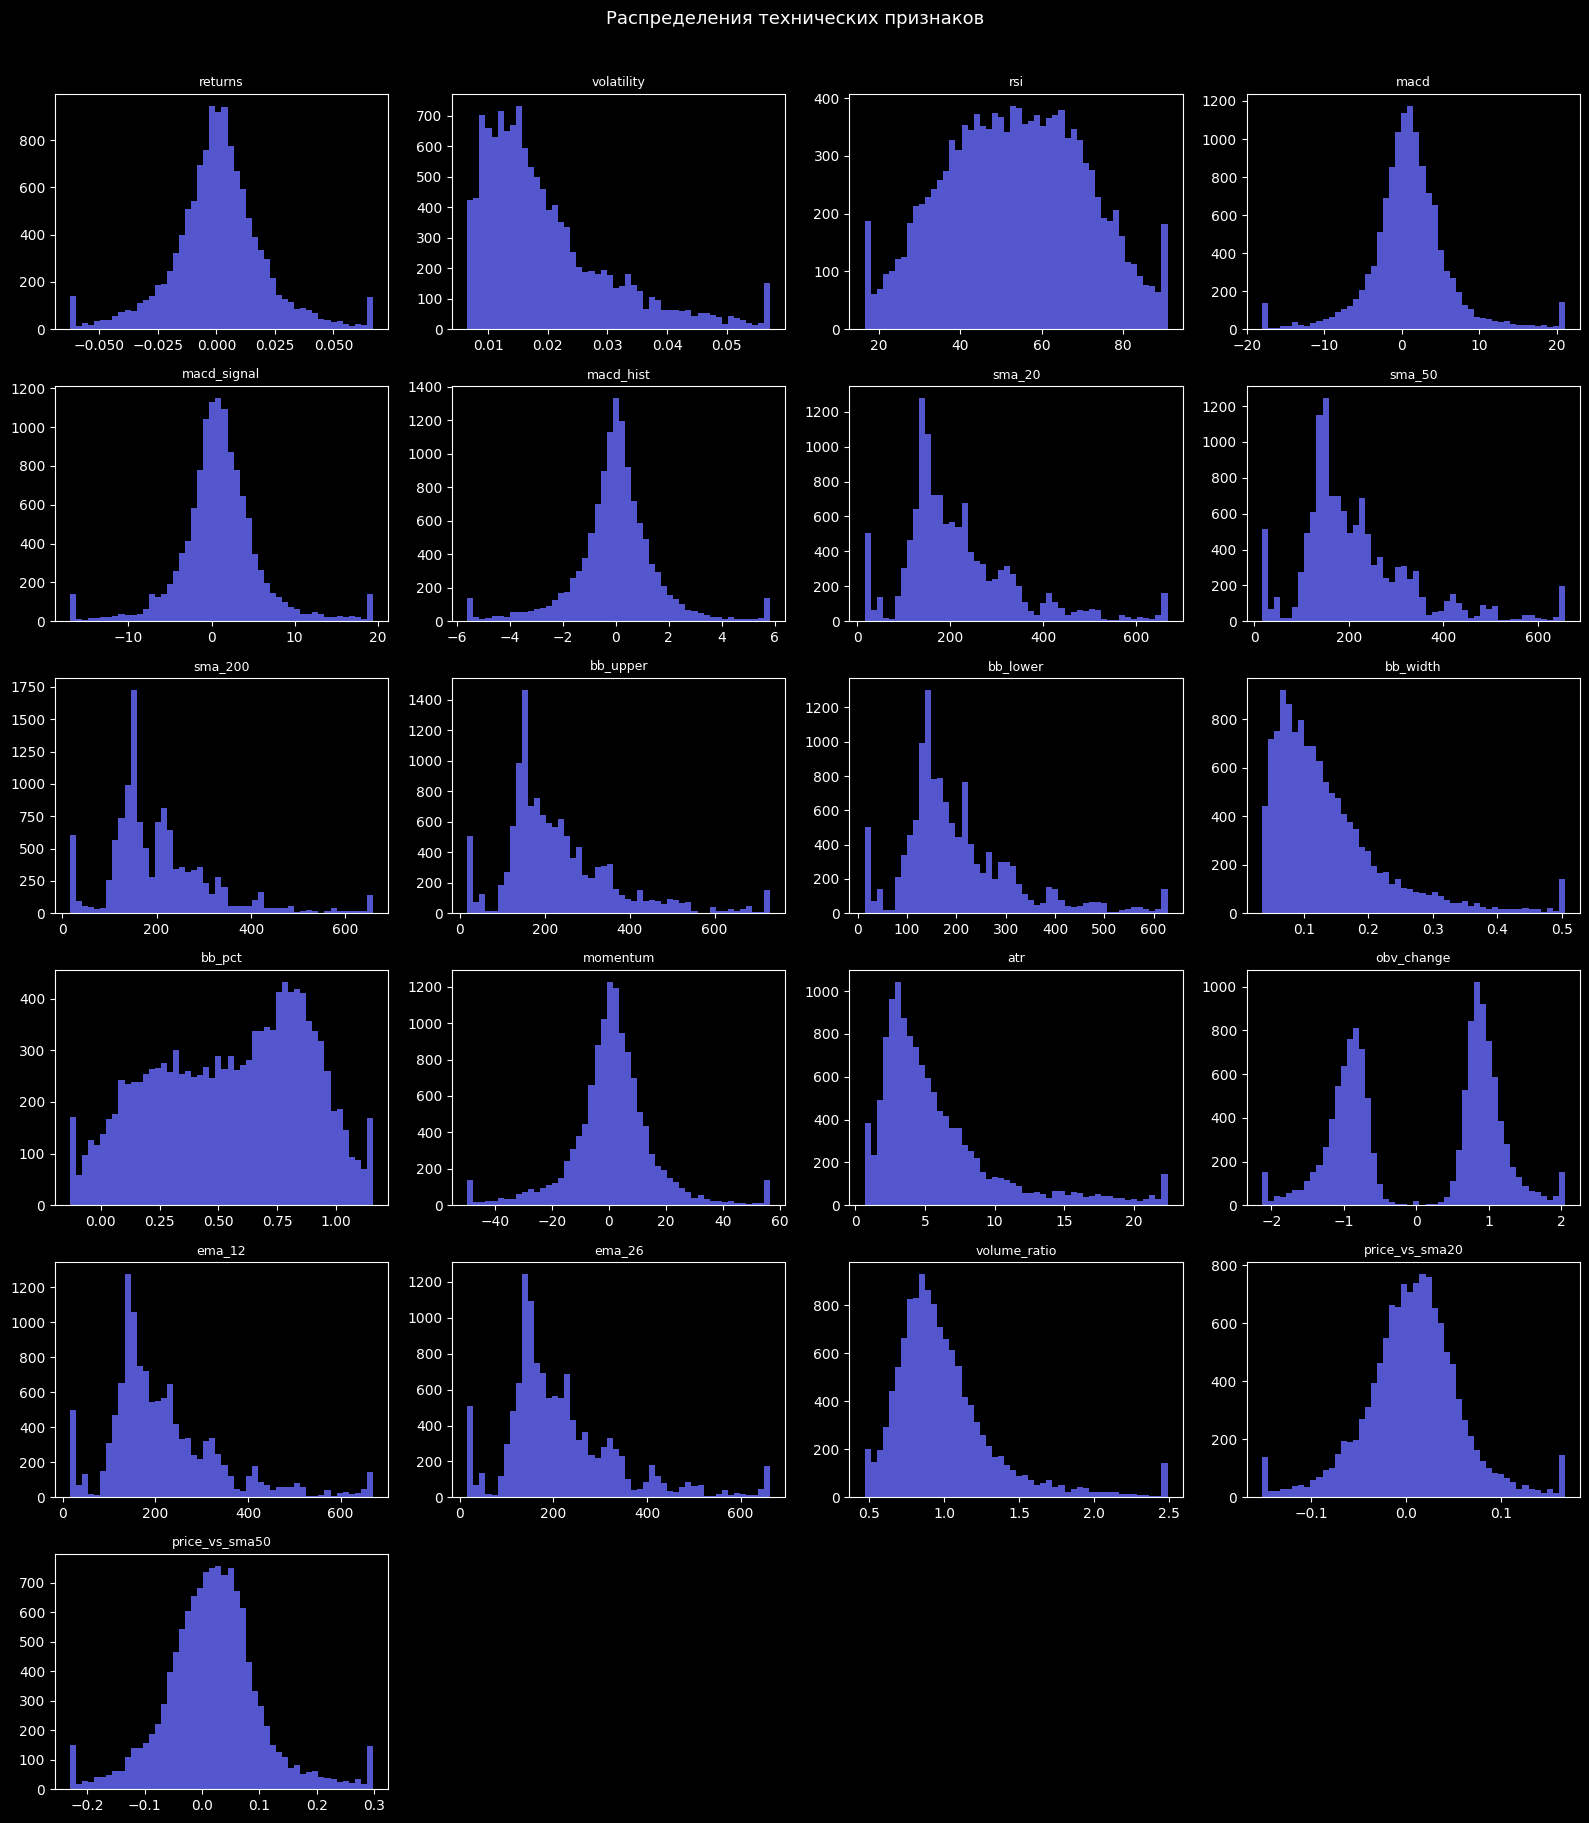

In [6]:
sample = combined[TECHNICAL_FEATURES].dropna()

n_cols = 4
n_rows = (len(TECHNICAL_FEATURES) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(TECHNICAL_FEATURES):
    data = sample[col].dropna()
    lo, hi = data.quantile(0.01), data.quantile(0.99)
    axes[i].hist(data.clip(lo, hi), bins=50, color='#6366f1', alpha=0.85)
    axes[i].set_title(col, fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Распределения технических признаков', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Lag-признаки

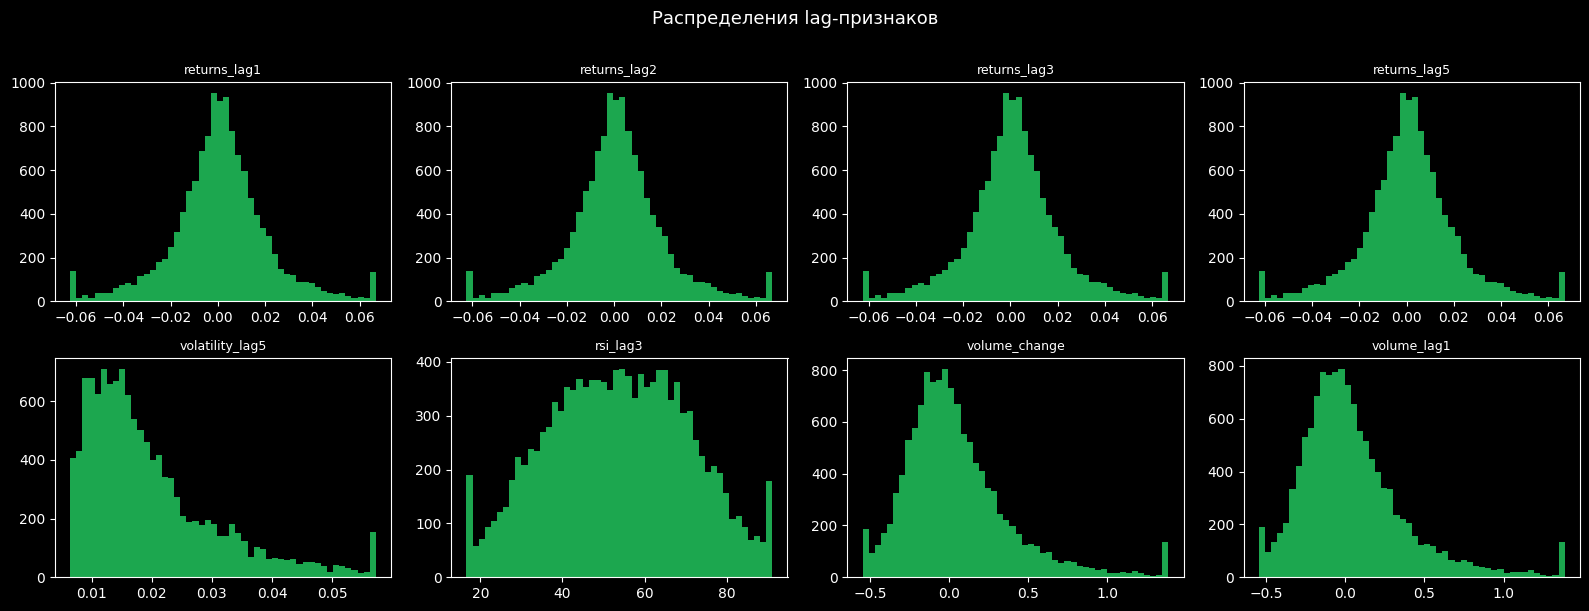

In [7]:
lag_sample = combined[LAG_FEATURES].dropna()

n_cols = 4
n_rows = (len(LAG_FEATURES) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(LAG_FEATURES):
    data = lag_sample[col].dropna()
    lo, hi = data.quantile(0.01), data.quantile(0.99)
    axes[i].hist(data.clip(lo, hi), bins=50, color='#22c55e', alpha=0.85)
    axes[i].set_title(col, fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Распределения lag-признаков', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 6. Корреляционная матрица

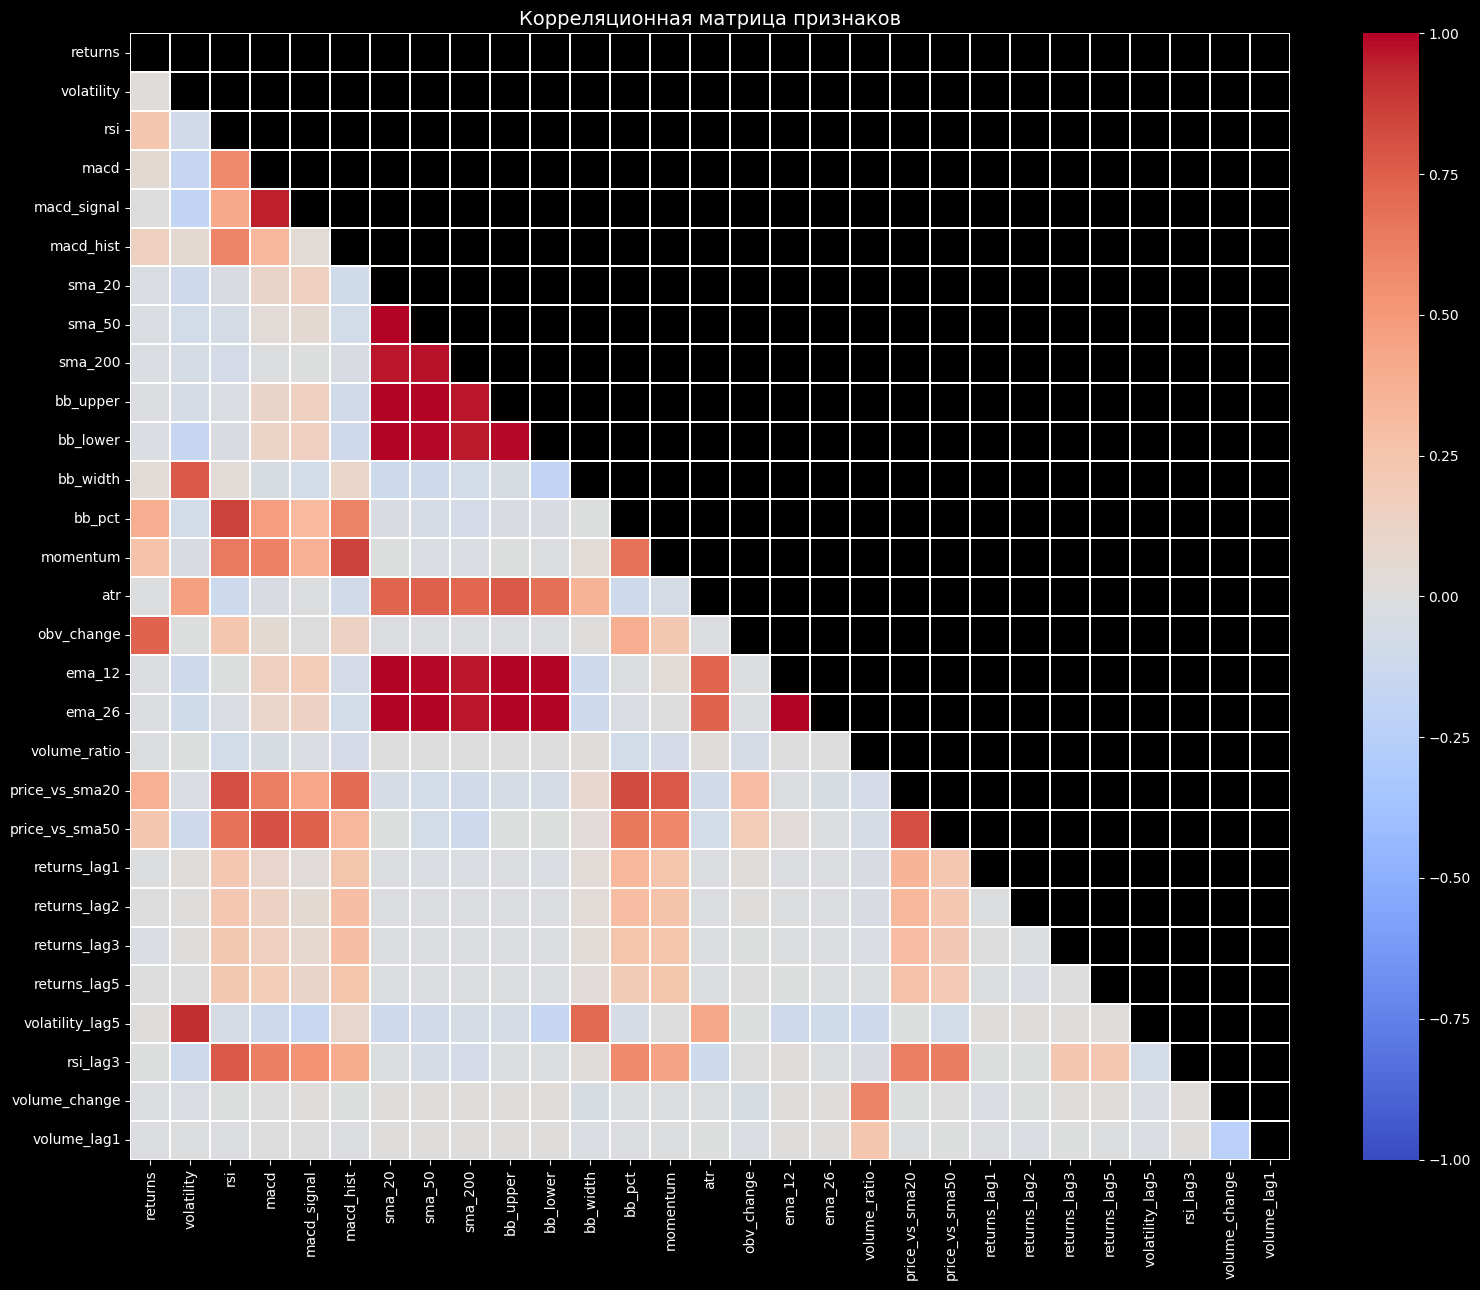

Высокая корреляция (|r| > 0.85): 25 пар
  sma_20               ↔ ema_26              : 1.000
  sma_20               ↔ ema_12              : 0.999
  ema_12               ↔ ema_26              : 0.999
  sma_20               ↔ bb_upper            : 0.997
  sma_50               ↔ ema_26              : 0.997
  bb_upper             ↔ ema_26              : 0.997
  bb_upper             ↔ ema_12              : 0.996
  sma_20               ↔ bb_lower            : 0.996
  bb_lower             ↔ ema_26              : 0.995
  sma_20               ↔ sma_50              : 0.995
  bb_lower             ↔ ema_12              : 0.995
  sma_50               ↔ bb_upper            : 0.992
  sma_50               ↔ ema_12              : 0.992
  sma_50               ↔ bb_lower            : 0.990
  bb_upper             ↔ bb_lower            : 0.985


In [8]:
corr = combined[all_features].dropna().corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=False, cmap='coolwarm',
    center=0, vmin=-1, vmax=1, linewidths=0.2, ax=ax,
)
ax.set_title('Корреляционная матрица признаков', fontsize=14)
plt.tight_layout()
plt.show()

high_corr = [
    (c1, c2, corr.loc[c1, c2])
    for i, c1 in enumerate(corr.columns)
    for c2 in corr.columns[i + 1:]
    if abs(corr.loc[c1, c2]) > 0.85
]
print(f'Высокая корреляция (|r| > 0.85): {len(high_corr)} пар')
for c1, c2, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True)[:15]:
    print(f'  {c1:20s} ↔ {c2:20s}: {r:.3f}')

## 7. Целевая переменная

Up: 6589  Down: 5971  →  Positive rate: 52.5%


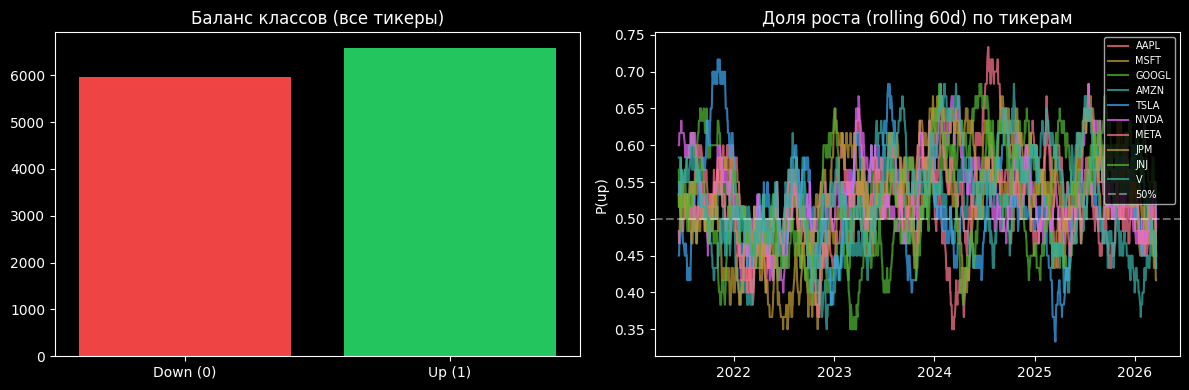

In [9]:
def make_target(df: pd.DataFrame, horizon: int = 1) -> pd.DataFrame:
    df = df.copy().sort_values('date')
    df['target'] = (df['returns'].shift(-horizon) > 0).astype(int)
    return df


combined_t = make_target(combined, horizon=1)
counts = combined_t['target'].value_counts()
pos_rate = counts.get(1, 0) / len(combined_t) * 100
print(f'Up: {counts.get(1, 0)}  Down: {counts.get(0, 0)}  →  Positive rate: {pos_rate:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['Down (0)', 'Up (1)'], [counts.get(0, 0), counts.get(1, 0)],
            color=['#ef4444', '#22c55e'])
axes[0].set_title('Баланс классов (все тикеры)')

for ticker, df in feature_frames.items():
    df_t = make_target(df).sort_values('date')
    roll = df_t['target'].rolling(60).mean()
    axes[1].plot(pd.to_datetime(df_t['date']), roll, label=ticker, alpha=0.75)

axes[1].axhline(0.5, color='white', linestyle='--', alpha=0.4, label='50%')
axes[1].set_title('Доля роста (rolling 60d) по тикерам')
axes[1].set_ylabel('P(up)')
axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()

## 8. Динамика returns и RSI

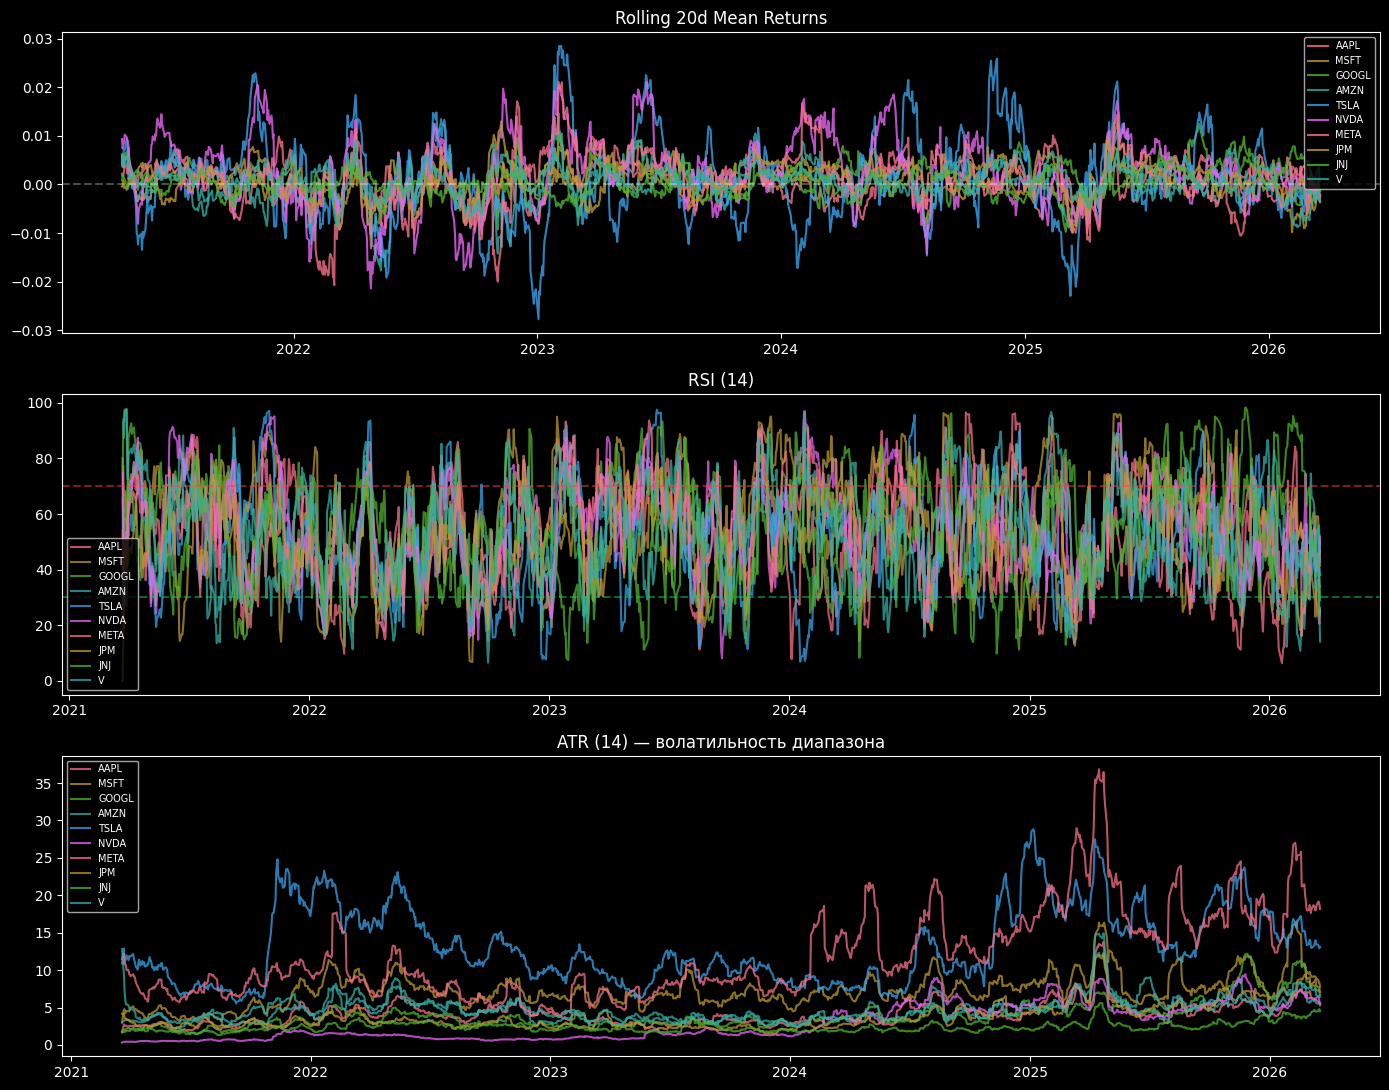

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=False)

for ticker, df in feature_frames.items():
    d = df.sort_values('date')
    axes[0].plot(pd.to_datetime(d['date']), d['returns'].rolling(20).mean(),
                 label=ticker, alpha=0.8)
axes[0].axhline(0, color='white', linestyle='--', alpha=0.3)
axes[0].set_title('Rolling 20d Mean Returns')
axes[0].legend(fontsize=7)

for ticker, df in feature_frames.items():
    d = df.sort_values('date')
    axes[1].plot(pd.to_datetime(d['date']), d['rsi'], label=ticker, alpha=0.75)
axes[1].axhline(70, color='#ef4444', linestyle='--', alpha=0.5)
axes[1].axhline(30, color='#22c55e', linestyle='--', alpha=0.5)
axes[1].set_title('RSI (14)')
axes[1].legend(fontsize=7)

for ticker, df in feature_frames.items():
    d = df.sort_values('date')
    axes[2].plot(pd.to_datetime(d['date']), d['atr'], label=ticker, alpha=0.75)
axes[2].set_title('ATR (14) — волатильность диапазона')
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.show()

## 9. Предиктивная сила признаков (point-biserial correlation с target)

Топ-15 признаков по связи с target:
                        r         p significant
returns            0.2521       0.0        True
obv_change       0.208846       0.0        True
bb_pct           0.111127       0.0        True
price_vs_sma20   0.096507       0.0        True
momentum         0.070015       0.0        True
rsi              0.066016       0.0        True
price_vs_sma50   0.065148       0.0        True
volume_change   -0.040443  0.000006        True
macd_hist         0.03142  0.000454        True
volume_ratio     -0.02549  0.004451        True
macd             0.024265  0.006776        True
macd_signal      0.015621  0.081348       False
returns_lag1     0.012323  0.169154       False
volatility_lag5 -0.011497  0.199586       False
rsi_lag3        -0.008508  0.342478       False


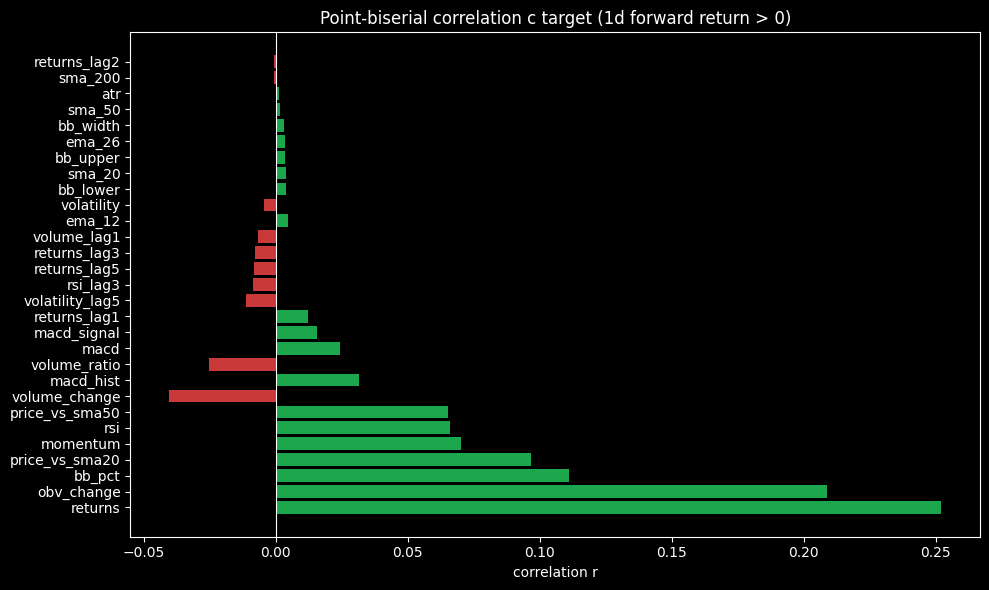

In [11]:
from scipy import stats as scipy_stats

df_clean = combined_t[all_features + ['target']].dropna()

pb_corr = {}
for feat in all_features:
    r, p = scipy_stats.pointbiserialr(df_clean['target'], df_clean[feat])
    pb_corr[feat] = {'r': r, 'p': p, 'significant': p < 0.05}

pb_df = pd.DataFrame(pb_corr).T.sort_values('r', key=abs, ascending=False)
print('Топ-15 признаков по связи с target:')
print(pb_df.head(15).round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#22c55e' if r > 0 else '#ef4444' for r in pb_df['r']]
ax.barh(pb_df.index, pb_df['r'], color=colors, alpha=0.85)
ax.axvline(0, color='white', linewidth=0.8)
ax.set_title('Point-biserial correlation с target (1d forward return > 0)')
ax.set_xlabel('correlation r')
plt.tight_layout()
plt.show()

## 10. Сохранение обработанных данных

In [12]:
for ticker, df in feature_frames.items():
    out_dir = PROCESSED_DIR / ticker
    out_dir.mkdir(parents=True, exist_ok=True)

    df_clean = df.dropna(subset=TECHNICAL_FEATURES).copy()
    tech_cols = ['date', 'close'] + TECHNICAL_FEATURES + LAG_FEATURES
    tech_df = df_clean[[c for c in tech_cols if c in df_clean.columns]]

    out_path = out_dir / 'technical.parquet'
    tech_df.to_parquet(out_path, index=False)
    print(f'{ticker}: {len(tech_df)} строк → {out_path}')

print('\nГотово.')

AAPL: 1246 строк → /Users/dimabogolaev/EquiSense/data/processed/AAPL/technical.parquet
MSFT: 1246 строк → /Users/dimabogolaev/EquiSense/data/processed/MSFT/technical.parquet
GOOGL: 1246 строк → /Users/dimabogolaev/EquiSense/data/processed/GOOGL/technical.parquet
AMZN: 1246 строк → /Users/dimabogolaev/EquiSense/data/processed/AMZN/technical.parquet
TSLA: 1246 строк → /Users/dimabogolaev/EquiSense/data/processed/TSLA/technical.parquet
NVDA: 1246 строк → /Users/dimabogolaev/EquiSense/data/processed/NVDA/technical.parquet
META: 1239 строк → /Users/dimabogolaev/EquiSense/data/processed/META/technical.parquet
JPM: 1246 строк → /Users/dimabogolaev/EquiSense/data/processed/JPM/technical.parquet
JNJ: 1246 строк → /Users/dimabogolaev/EquiSense/data/processed/JNJ/technical.parquet
V: 1246 строк → /Users/dimabogolaev/EquiSense/data/processed/V/technical.parquet

Готово.
